In [234]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_human_capital import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim

par.solver = 'brentq'

model.solve(do_print=True)

params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Convergence achieved at iteration 97 with eps = 7.79e-09


The model converges to the steady state:

In [235]:
print(f"Workers supply in high jobs: {[f'{x:.2f}' for x in par.l_h_ss]}")
print(f"Workers supply in low jobs: {[f'{x:.2f}' for x in par.l_l_ss]}")
print(f"Wage of workers in high jobs: {[f'{x:.2f}' for x in par.wage_h_ss]}")
print(f"Wage of workers in low jobs: {[f'{x:.2f}' for x in par.wage_l_ss]}")

Workers supply in high jobs: ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.14', '0.14', '0.15', '0.16', '0.17', '0.17', '0.18', '0.19', '0.19', '0.19', '0.19', '0.19', '0.19', '0.18', '0.17', '0.16', '0.15', '0.13', '0.12', '0.10', '0.08', '0.07', '0.05', '0.04', '0.02', '0.02', '0.01', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
Workers supply in low jobs: ['1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.99', '0.85', '0.84', '0.83', '0.81', '0.79', '0.77', '0.75', '0.73', '0.70', '0.67', '0.64', '0.60', '0.56', '0.52', '0.47', '0.42', '0.37', '0.32', '0.27', '0.23', '0.18', '0.14', '0.10', '0.07', '0.05', '0.03', '0.02', '0.01', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
Wage of workers in high jobs: ['0.24', '0.24', '0.24', '0.24', '0.25', '0.25', '0.25', '0.26', '0.26', '0.27', '0.27', '0.28', '0.28', '0.29'

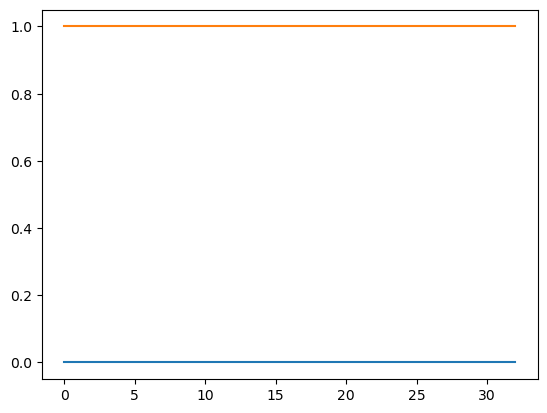

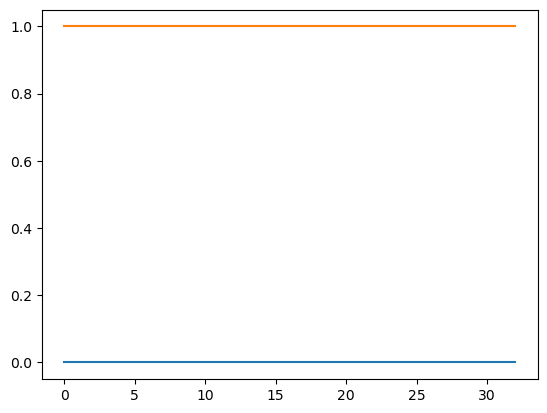

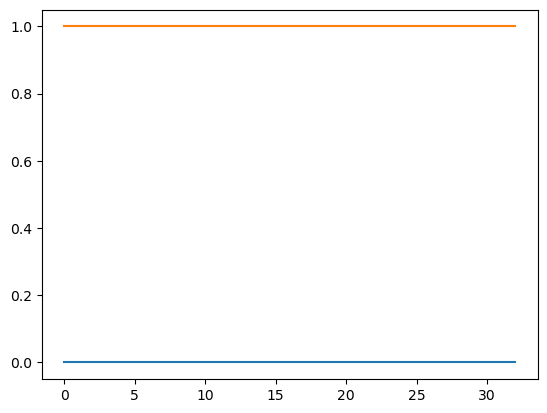

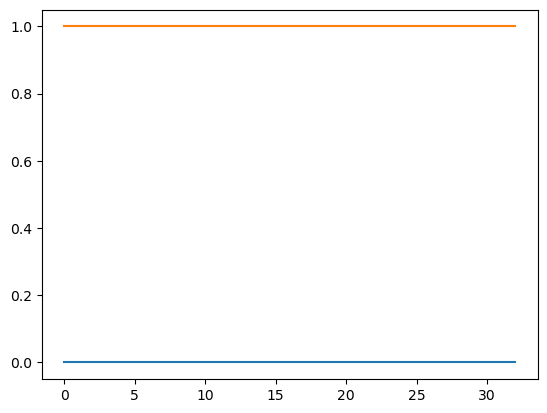

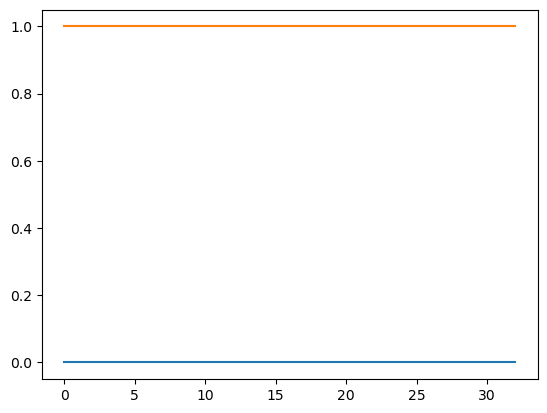

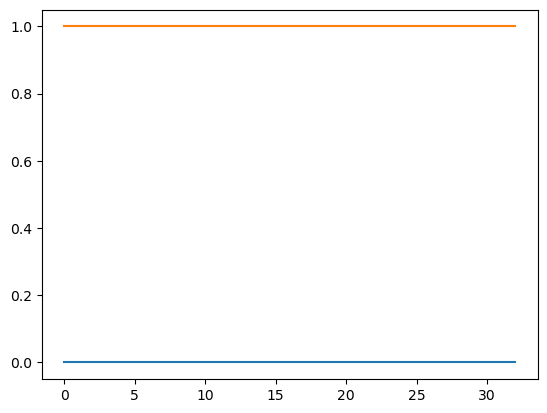

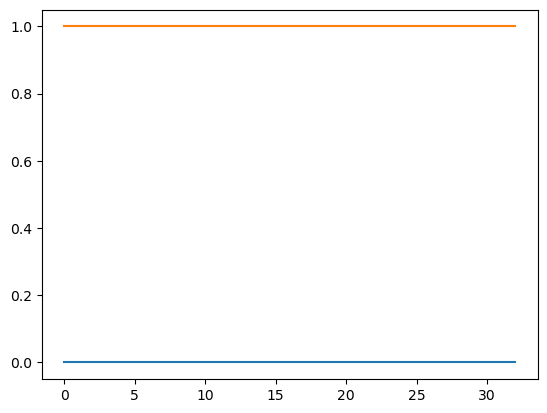

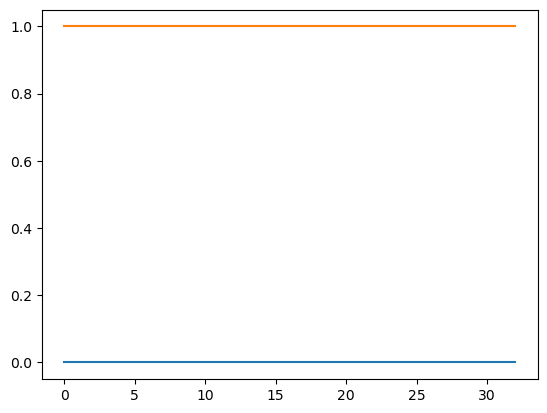

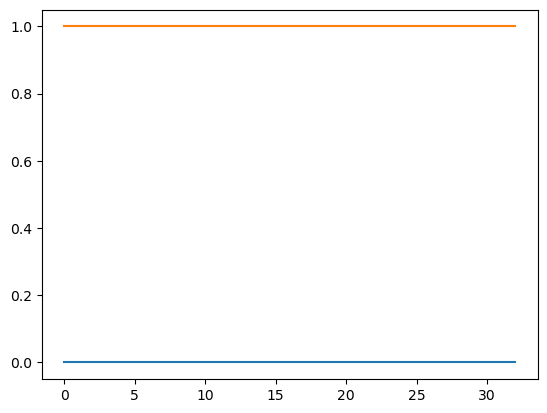

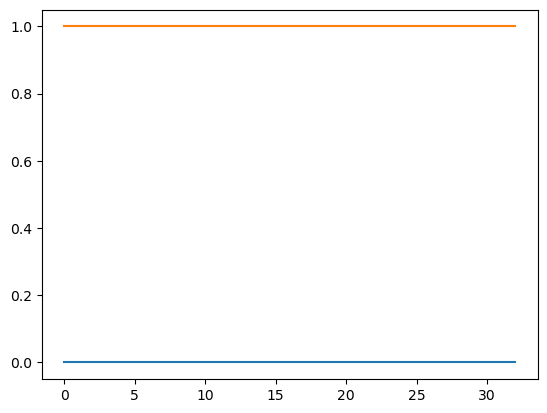

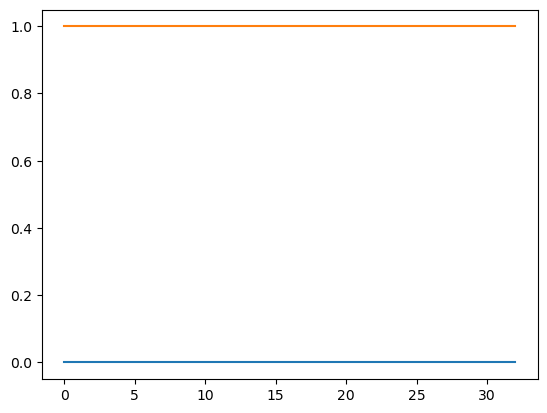

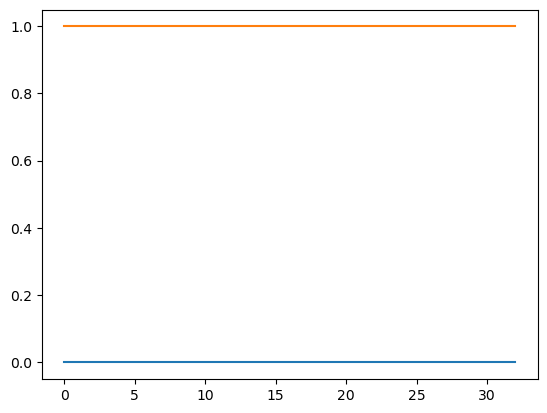

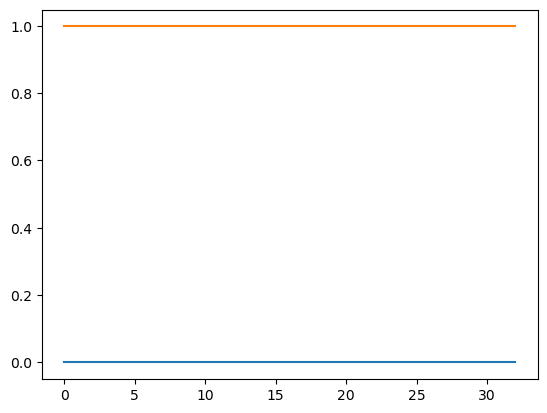

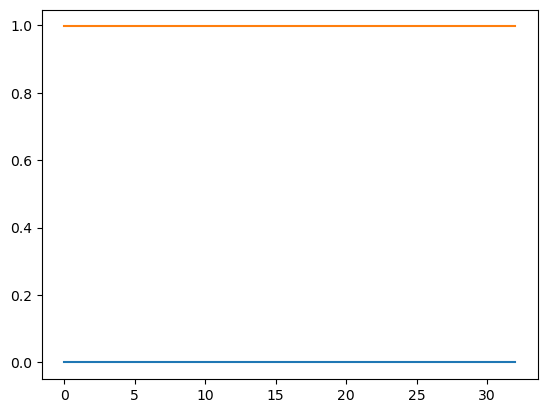

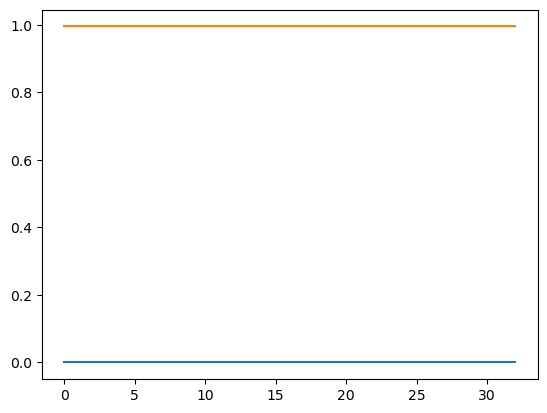

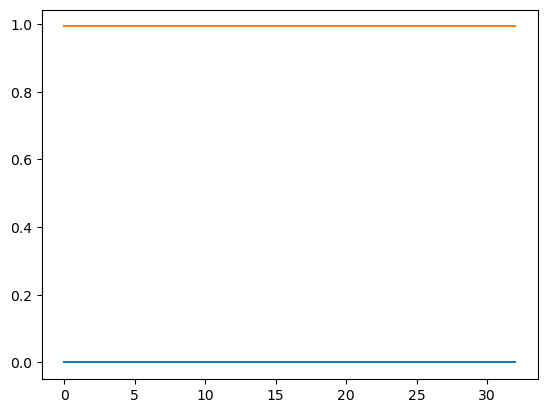

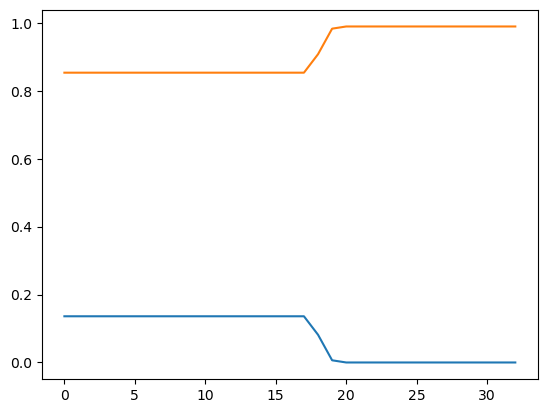

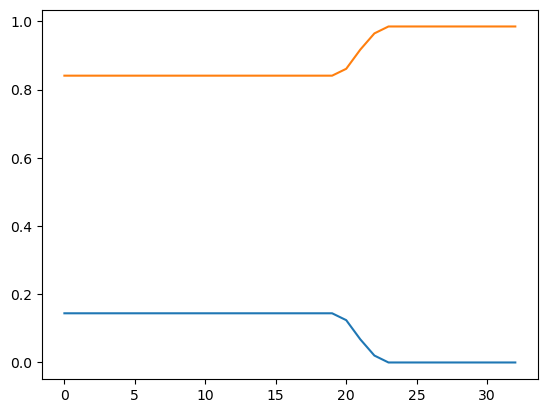

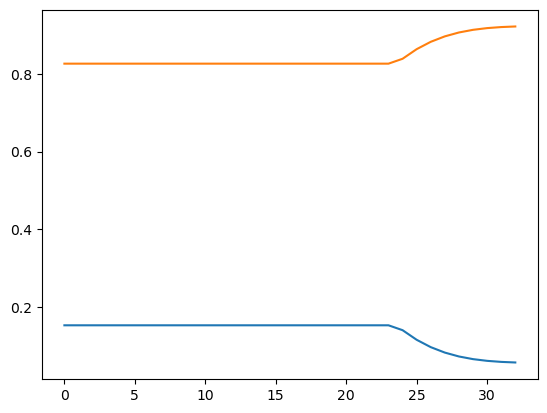

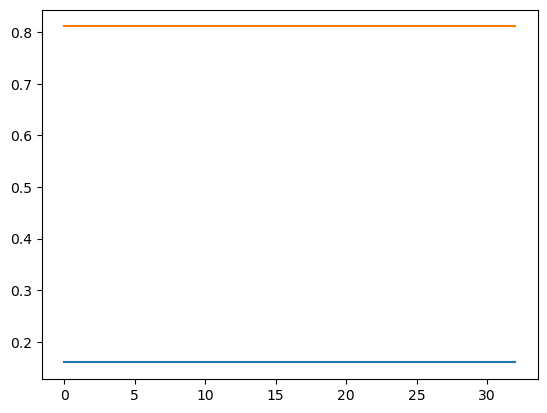

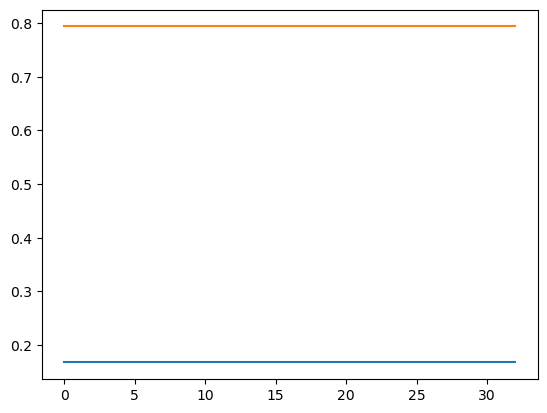

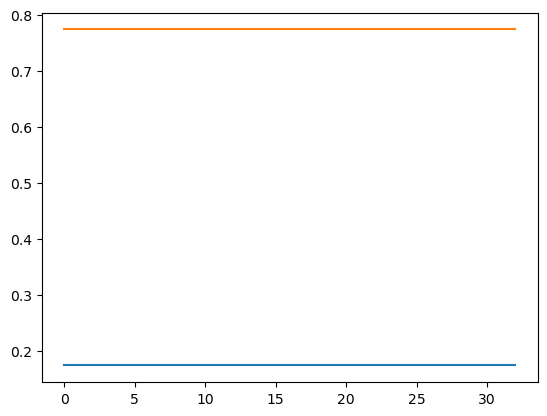

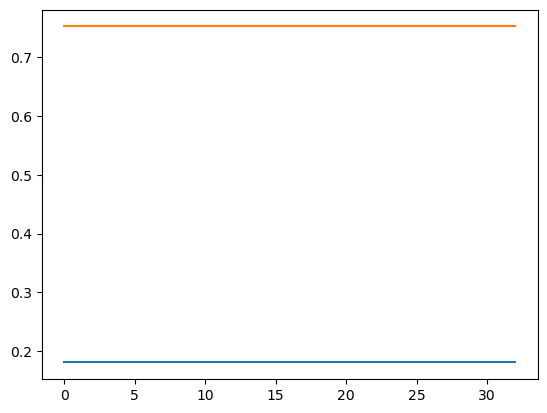

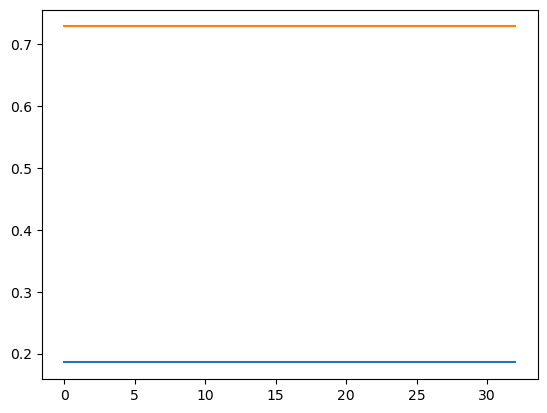

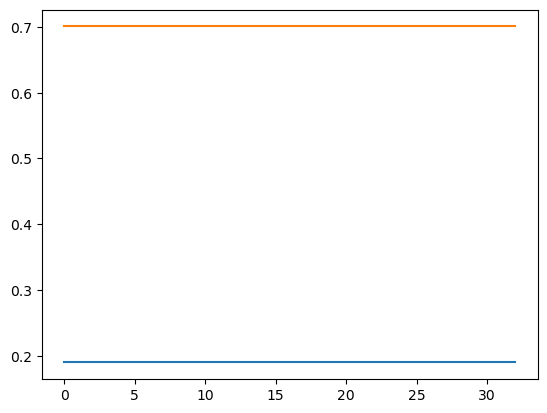

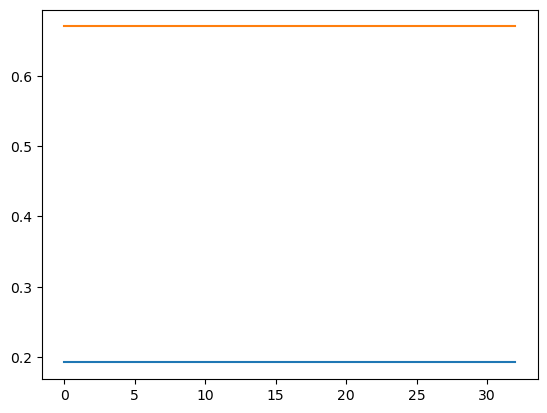

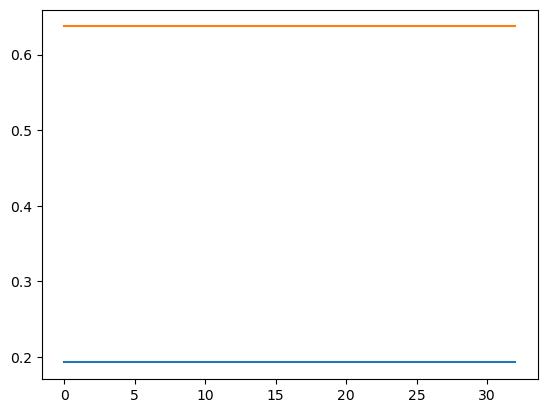

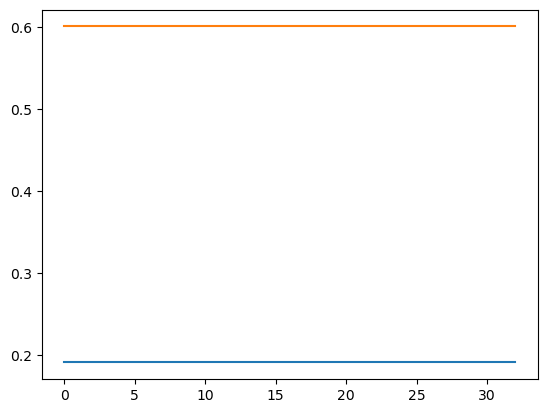

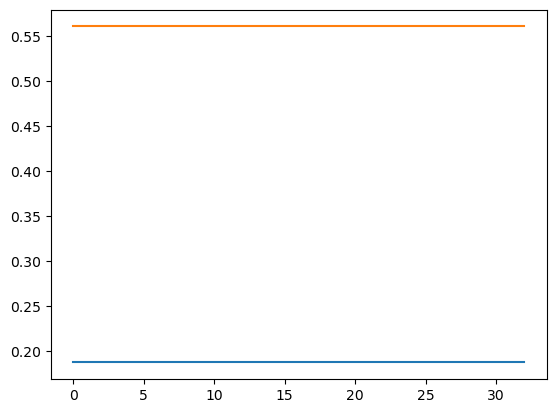

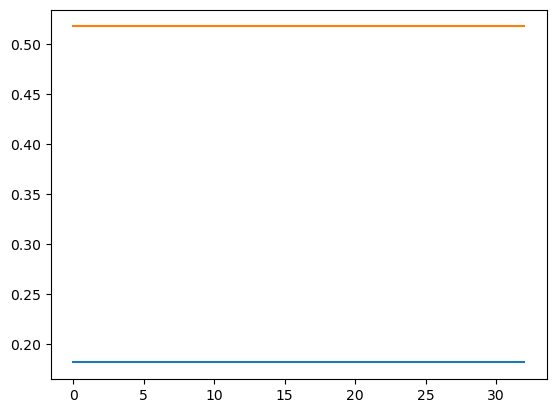

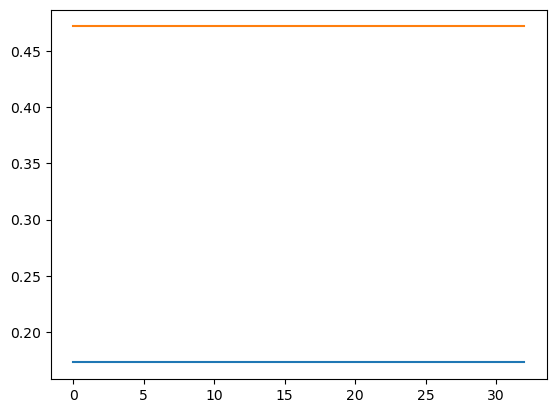

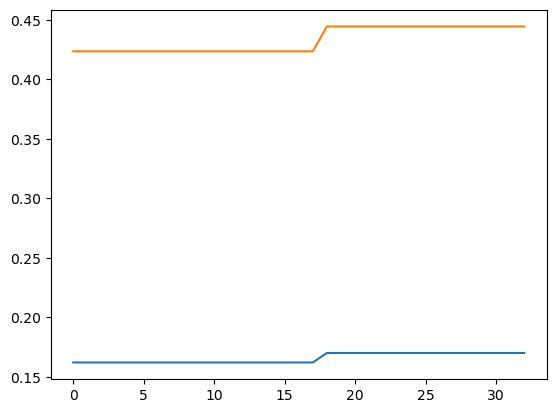

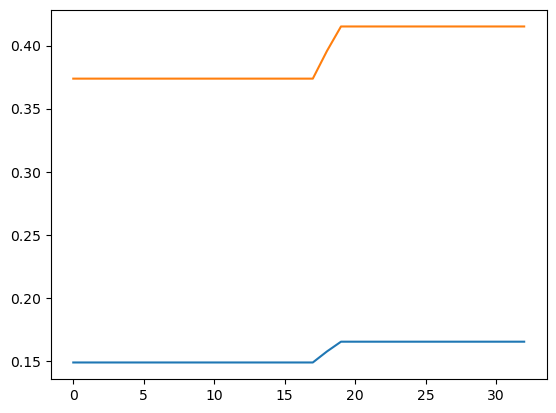

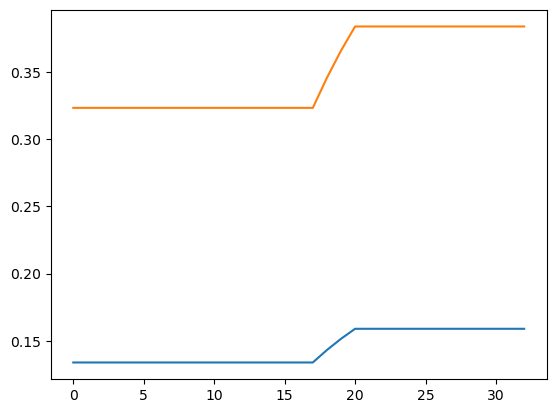

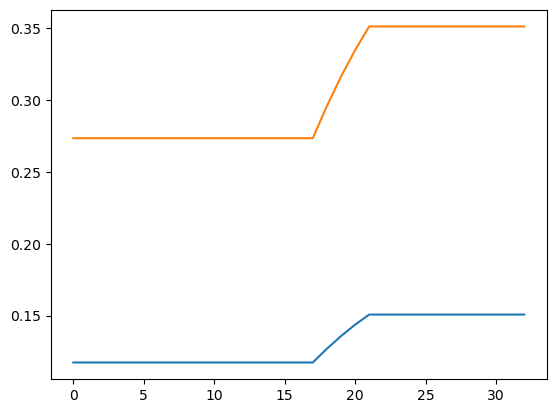

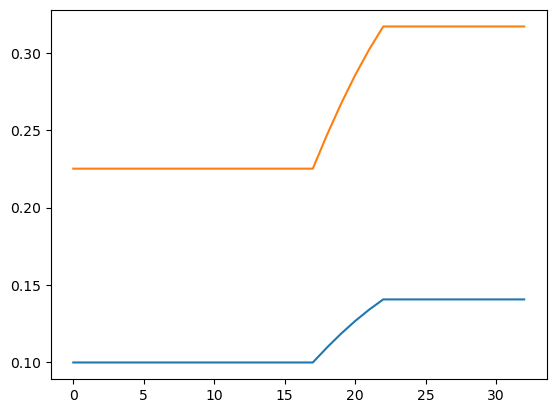

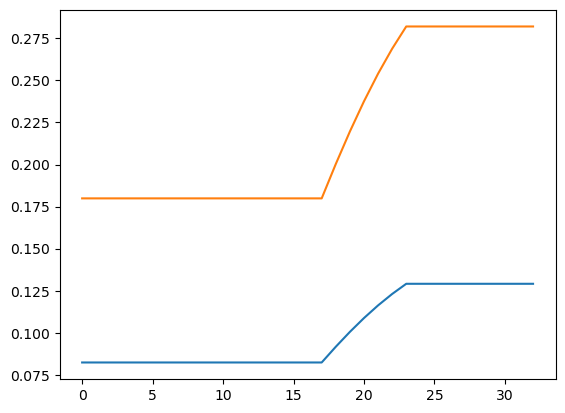

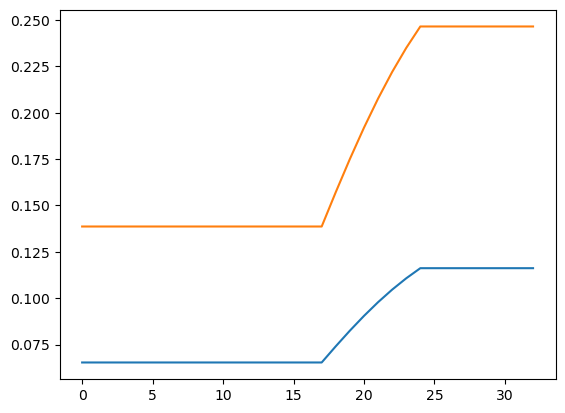

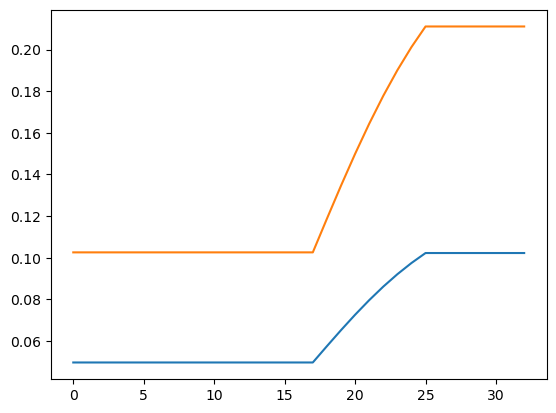

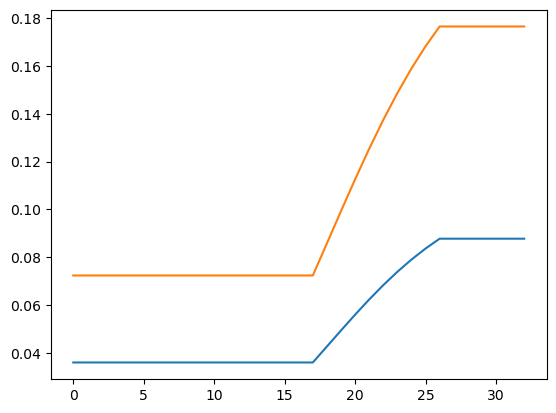

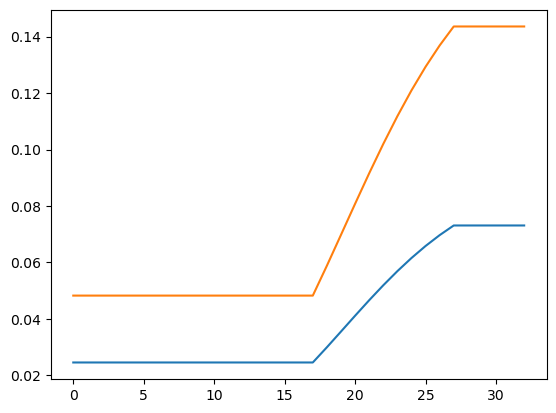

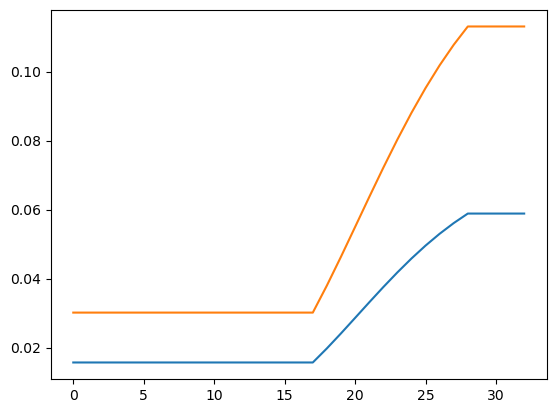

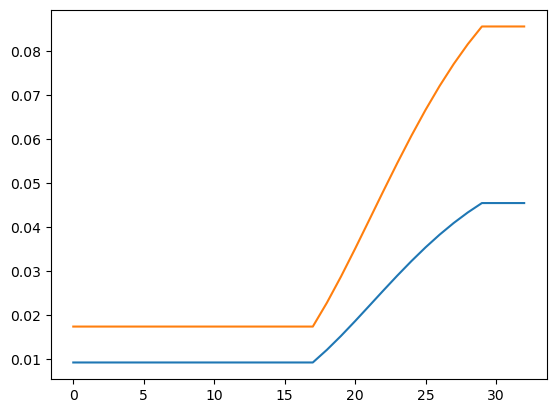

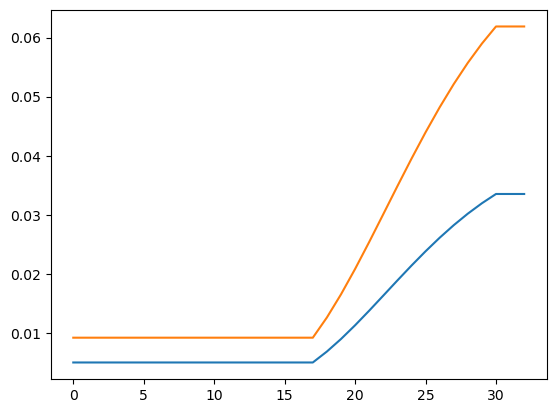

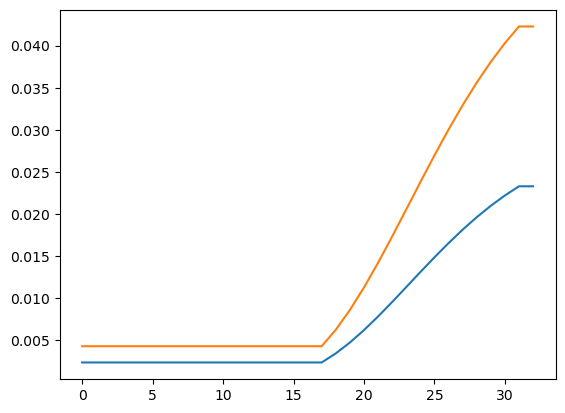

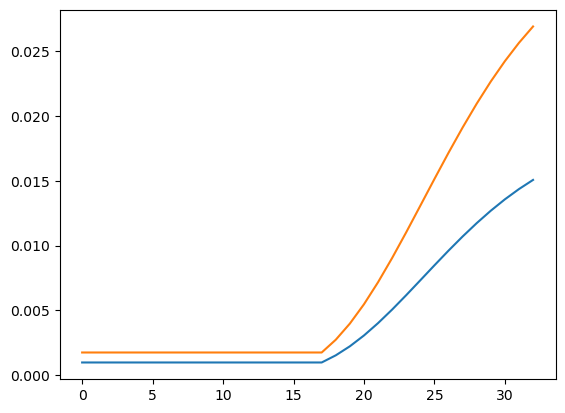

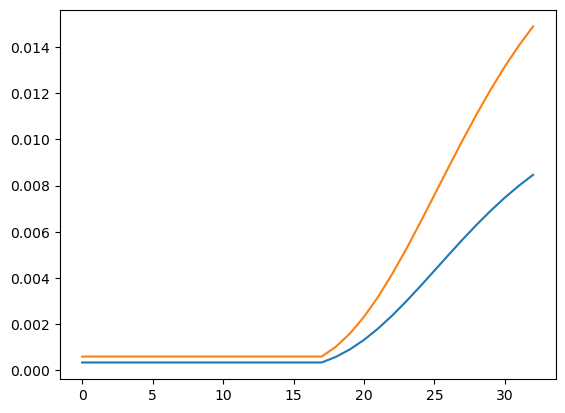

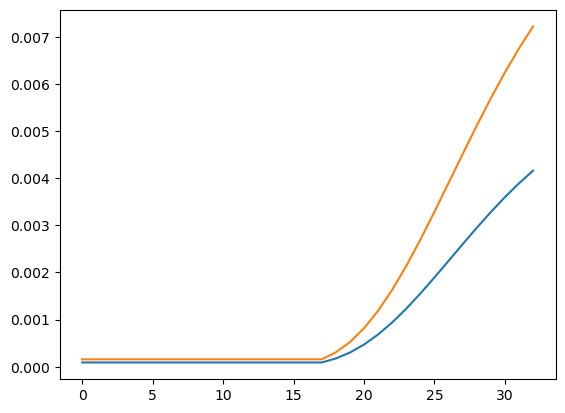

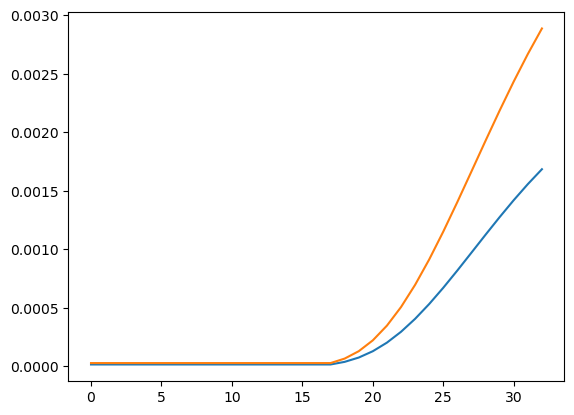

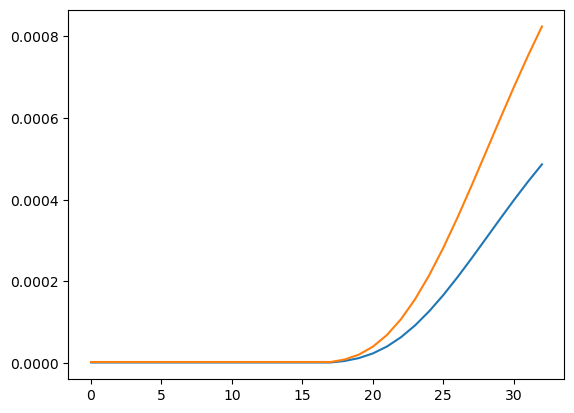

In [236]:
model.simulate_transition()

for i in range(par.n):
    plt.plot(model.sim.l_h[:, i])
    plt.plot(model.sim.l_l[:, i])
    plt.show()

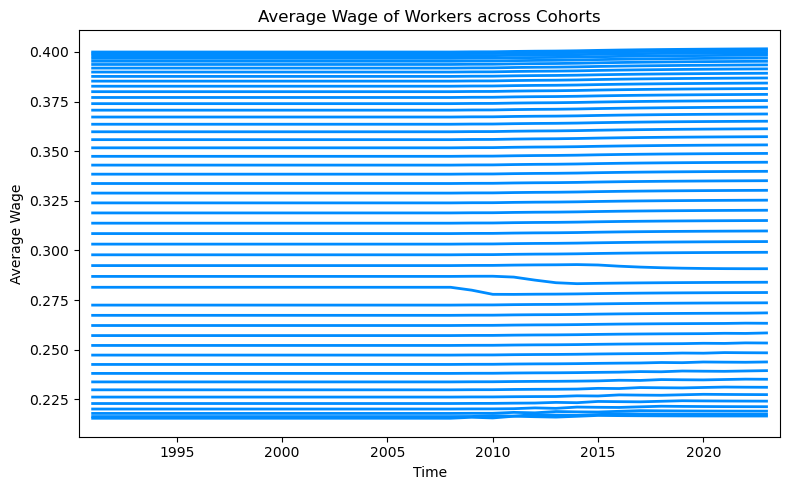

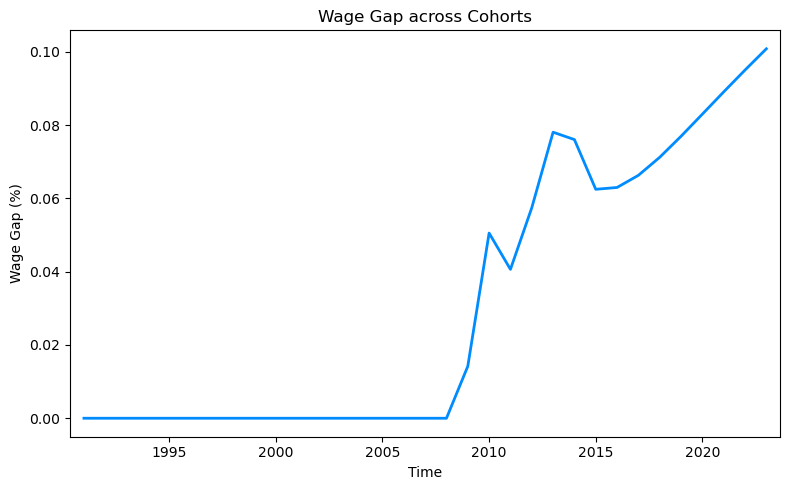

In [241]:
plot_series(model.sim.avg_wage[:, :], title="Average Wage of Workers across Cohorts", ylabel="Average Wage")

wage_gap = (np.average(model.sim.avg_wage[:, -5::]/model.sim.avg_wage[0, -5::], axis=1) - np.average(model.sim.avg_wage[:, :20]/model.sim.avg_wage[0, :20], axis=1))*100
plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")

In [242]:
A_mat = np.ones((33, par.n))*np.arange(0, par.n, 1)

B_mat = model.sim.l_h / (model.sim.l_h + model.sim.l_l)

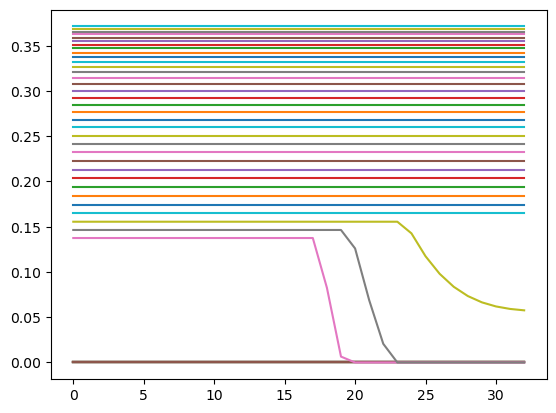

In [243]:
plt.plot(B_mat)

In [244]:
par.rho_transition

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.9999999 , 0.9999999 , 0.9999999 , ..., 0.9999999 , 0.9999999 ,
        0.9999999 ],
       [0.99999922, 0.99999922, 0.99999922, ..., 0.99999922, 0.99999922,
        0.99999922],
       ...,
       [0.26609598, 0.26609598, 0.26609598, ..., 0.51584492, 0.51584492,
        0.51584492],
       [0.1846273 , 0.1846273 , 0.1846273 , ..., 0.42968279, 0.42968279,
        0.42968279],
       [0.0960792 , 0.0960792 , 0.0960792 , ..., 0.30996645, 0.30996645,
        0.30996645]])

In [245]:
A_mat

array([[ 0.,  1.,  2., ..., 47., 48., 49.],
       [ 0.,  1.,  2., ..., 47., 48., 49.],
       [ 0.,  1.,  2., ..., 47., 48., 49.],
       ...,
       [ 0.,  1.,  2., ..., 47., 48., 49.],
       [ 0.,  1.,  2., ..., 47., 48., 49.],
       [ 0.,  1.,  2., ..., 47., 48., 49.]])

In [246]:
B_mat

array([[0.        , 0.        , 0.        , ..., 0.36558816, 0.3685215 ,
        0.37122447],
       [0.        , 0.        , 0.        , ..., 0.36558816, 0.3685215 ,
        0.37122447],
       [0.        , 0.        , 0.        , ..., 0.36558816, 0.3685215 ,
        0.37122447],
       ...,
       [0.        , 0.        , 0.        , ..., 0.36558816, 0.3685215 ,
        0.37122447],
       [0.        , 0.        , 0.        , ..., 0.36558816, 0.3685215 ,
        0.37122447],
       [0.        , 0.        , 0.        , ..., 0.36558816, 0.3685215 ,
        0.37122447]])

In [247]:
np.sum(A_mat * B_mat, axis=1)

array([328.29183028, 328.29183028, 328.29183028, 328.29183028,
       328.29183028, 328.29183028, 328.29183028, 328.29183028,
       328.29183028, 328.29183028, 328.29183028, 328.29183028,
       328.29183028, 328.29183028, 328.29183028, 328.29183028,
       328.29183028, 328.29183028, 327.41262163, 326.19573086,
       325.74469825, 324.77364518, 323.9535062 , 323.60314998,
       323.3716642 , 322.91605112, 322.56744   , 322.30929459,
       322.12520249, 321.99956414, 321.91817783, 321.86869036,
       321.84088342])